In [1]:
# t-test
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# Generate two samples for demonstrate purposes
np.random.seed(42)
sample1 = np.random.normal(loc=10, scale=2, size=30)
sample2 = np.random.normal(loc=12, scale=2, size=30)

Results of Two-sample t-test:
T-statistic:-4.512913234547555
P-value:3.176506547470154e-05
Degree of Freedom: 58


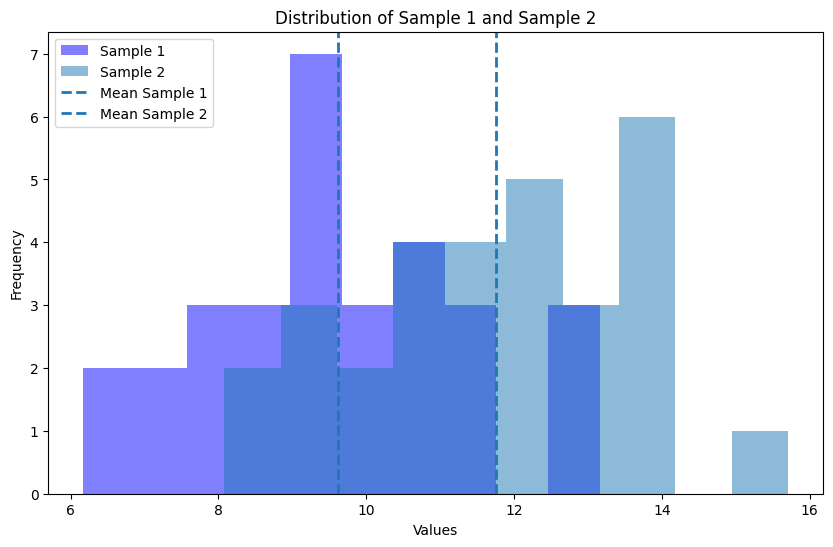

In [2]:
# Perform a two-sample t-test
t_statistic, p_value = stats.ttest_ind(sample1, sample2)

# Set the signifiacnt level
alpha = 0.05
print("Results of Two-sample t-test:")
print(f'T-statistic:{t_statistic}')
print(f'P-value:{p_value}')
print(f"Degree of Freedom: {len(sample1) + len(sample2)-2}")

# Plot the distributions
plt.figure(figsize = (10, 6))
plt.hist(sample1, alpha = 0.5, label = 'Sample 1', color = 'blue')
plt.hist(sample2, alpha=0.5, label='Sample 2')

plt.axvline(np.mean(sample1), linestyle='--', linewidth=2, label='Mean Sample 1')
plt.axvline(np.mean(sample2), linestyle='--', linewidth=2, label='Mean Sample 2')

plt.title('Distribution of Sample 1 and Sample 2')
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.legend()

plt.show()

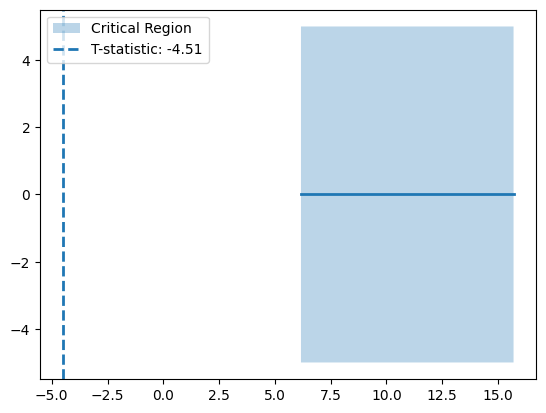

In [3]:
# Highlight the critical region if null hypothesis is rejected
if p_value < alpha:
    critical_region = np.linspace(
        min(sample1.min(), sample2.min()),
        max(sample1.max(), sample2.max()),
        1000
    )

    # Draw a baseline instead of an empty canvas
    plt.plot(critical_region, np.zeros_like(critical_region), linewidth=2)

    # Highlight critical region as a narrow band
    plt.fill_between(
        critical_region,
        -5,
        5,
        alpha=0.3,
        label='Critical Region'
    )

    # Mark the t-statistic clearly
    plt.axvline(
        t_statistic,
        linestyle='--',
        linewidth=2,
        label=f"T-statistic: {t_statistic:.2f}"
    )

    plt.legend()
    plt.show()


In [ ]:
# Draw Conclusions
if p_value < alpha:
    if np.mean(sample1) > np.mean(sample2):
        print("Conclusion: There is significant evidence to reject the null hypothesis.")
        print("Interpretation: The mean of Sample 1 is significantly higher than that of Sample 2.")
    else:
        print("Conclusion: There is significant evidence to reject the null hypothesis.")
        print("Interpretation: The mean of Sample 2 is significantly higher than that of Sample 1.")
else:
    print("Conclusion: Fail to reject the null hypothesis.")
    print("Interpretation: There is not enough evidence to claim a significant difference between the means.")

Conclusion: There is significant evidence to reject the null hypothesis.
Interpretation: The mean of Sample 2 is significantly higher than that of Sample 1.


In [5]:
#chi-test

import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sb
import warnings

from scipy import stats

warnings.filterwarnings('ignore')

df=sb.load_dataset('mpg')
print(df)

print(df['horsepower'].describe())
print(df['model_year'].describe())

bins=[0,75,150,240]
df['horsepower_new']=pd.cut(df['horsepower'],bins=bins,labels=['l','m','h'])
c=df['horsepower_new']
print(c)

ybins=[69,72,74,84]
label=['t1','t2','t3']
df['modelyear_new']=pd.cut(df['model_year'],bins=ybins,labels=label)
newyear=df['modelyear_new']
print(newyear)

df_chi=pd.crosstab(df['horsepower_new'],df['modelyear_new'])
print(df_chi)

print(stats.chi2_contingency(df_chi))

      mpg  cylinders  displacement  horsepower  weight  acceleration  \
0    18.0          8         307.0       130.0    3504          12.0   
1    15.0          8         350.0       165.0    3693          11.5   
2    18.0          8         318.0       150.0    3436          11.0   
3    16.0          8         304.0       150.0    3433          12.0   
4    17.0          8         302.0       140.0    3449          10.5   
..    ...        ...           ...         ...     ...           ...   
393  27.0          4         140.0        86.0    2790          15.6   
394  44.0          4          97.0        52.0    2130          24.6   
395  32.0          4         135.0        84.0    2295          11.6   
396  28.0          4         120.0        79.0    2625          18.6   
397  31.0          4         119.0        82.0    2720          19.4   

     model_year  origin                       name  
0            70     usa  chevrolet chevelle malibu  
1            70     usa      